In [2]:
import dadi, dadi.Polyploidy, dadi.DFE
import numpy as np
import matplotlib.pyplot as plt


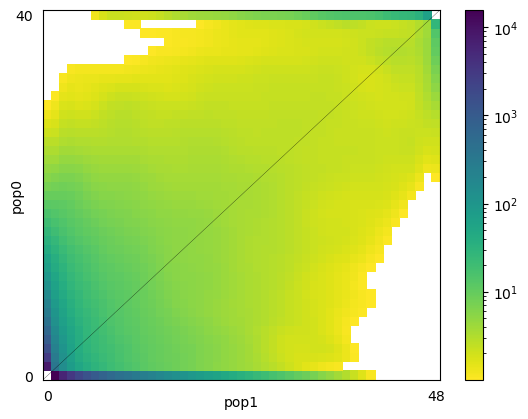

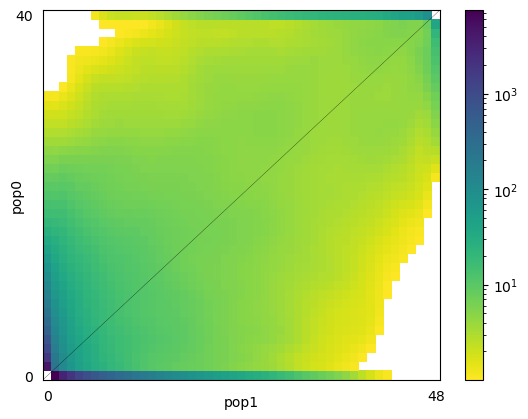

In [13]:
# load the data
nonsyn = dadi.Spectrum.from_file('nonsyn_sfs.sfs')
syn = dadi.Spectrum.from_file('syn_sfs.sfs')

# down project and plot
nonsyn_dp = nonsyn.project([40,48])
syn_dp = syn.project([40,48])
nonsyn_dp.mask[np.where(nonsyn_dp.data < 1)] = True
syn_dp.mask[np.where(syn_dp.data < 1)] = True
dadi.Plotting.plot_single_2d_sfs(nonsyn_dp)
dadi.Plotting.plot_single_2d_sfs(syn_dp)


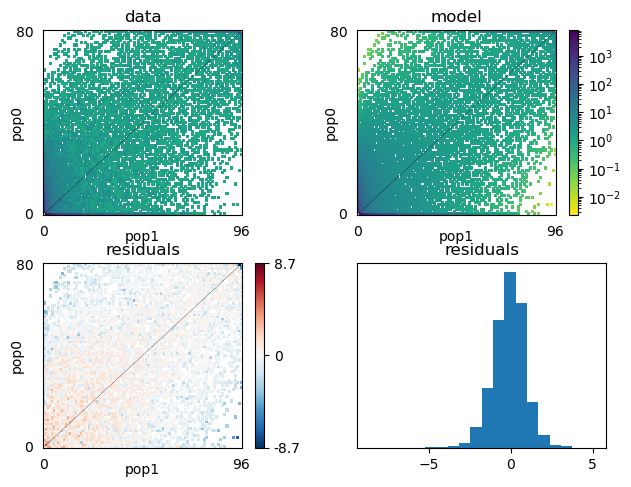

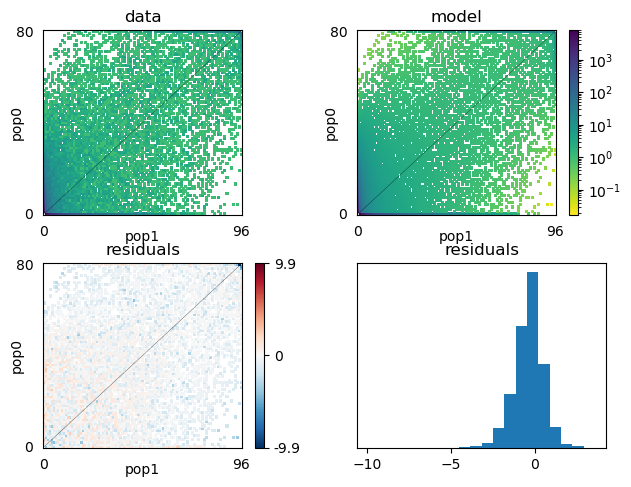

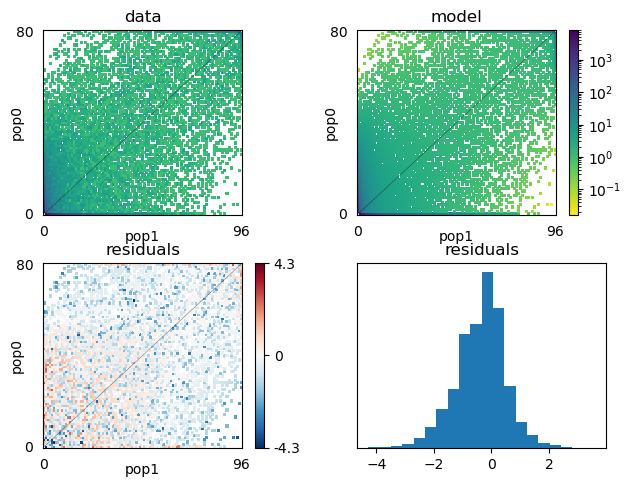

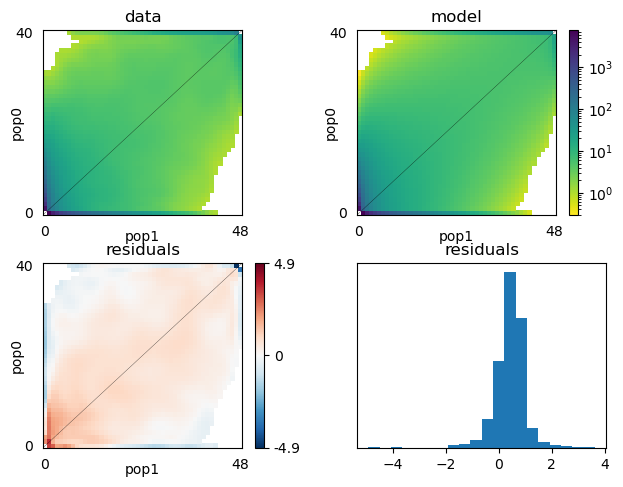

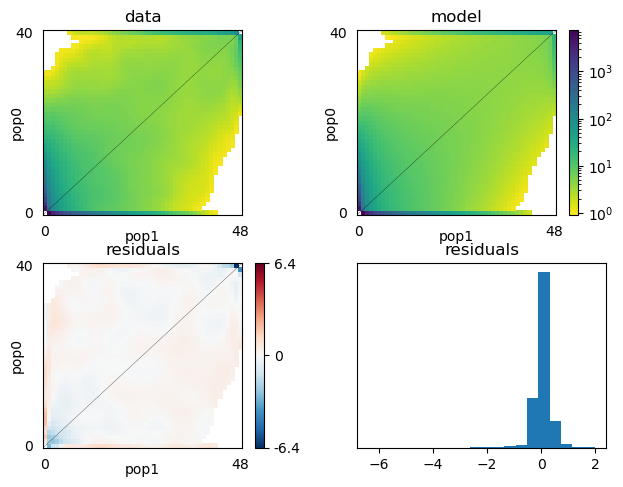

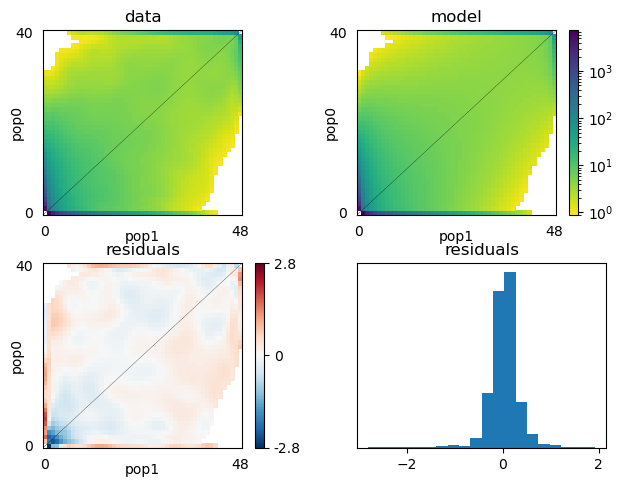

In [14]:
p_best = [0.0016501910884649047, 0.3340669742323613, 0.3237442449949602, 
          0.7657284403381766, 0.8831535064972048, 0.0, 1.2304164674431237]
theta_best = 5661.050416548915

p_best_misid = [0.05318934238469122, 0.29897609199973174, 0.3324157051675744,
                0.7856341253190582, 0.9101972856423438, 0.0, 1.2110779061347006, 0.005916388566846367]
theta_best_misid = 5534.219604596502

p_true = [0.15, 0.15, 0.3, 0.7, 0.8, 0.0, 2.0]
theta_true = 4 * 7e-9/3.5 * 5e6 * 161744

model = dadi.Polyploidy.auto_demographics.bottlegrowth_dip_size_change_asym_mig
model_ex = dadi.Numerics.make_extrap_func(model)
ns = syn.sample_sizes
pts_l = [max(ns)+101, max(ns)+111, max(ns)+121]

model_misid = dadi.Numerics.make_anc_state_misid_func(model)
model_misid_ex = dadi.Numerics.make_extrap_func(model_misid)

syn_model = theta_best * model_ex(p_best, ns, pts_l)

syn.mask[np.where(syn.data == 0)] = True

syn_model_true = theta_true * model_ex(p_true, ns, pts_l)
dadi.Plotting.plot_2d_comp_Poisson(syn_model_true, syn)

dadi.Plotting.plot_2d_comp_Poisson(syn_model, syn)

syn_model_misid = theta_best_misid * model_misid_ex(p_best_misid, ns, pts_l)
dadi.Plotting.plot_2d_comp_Poisson(syn_model_misid, syn)


ns = syn_dp.sample_sizes
pts_l = [max(ns)+101, max(ns)+111, max(ns)+121]
# also compare the to the down-projected data
syn_model_true_dp = theta_true * model_ex(p_true, ns, pts_l)
dadi.Plotting.plot_2d_comp_Poisson(syn_model_true_dp, syn_dp)

syn_model_dp = theta_best * model_ex(p_best, ns, pts_l)
dadi.Plotting.plot_2d_comp_Poisson(syn_model_dp, syn_dp)

syn_model_misid_dp = theta_best_misid * model_misid_ex(p_best_misid, ns, pts_l)
dadi.Plotting.plot_2d_comp_Poisson(syn_model_misid_dp, syn_dp)



In [15]:
# compute marginalized pi values for the data and true model
# then, report B-values

pi_data_dip = syn.marginalize([1]).pi()
pi_data_auto = syn.marginalize([0]).pi()

pi_true_dip = syn_model_true.marginalize([1]).pi()
pi_true_auto = syn_model_true.marginalize([0]).pi()

pi_inferred_dip = syn_model.marginalize([1]).pi()
pi_inferred_auto = syn_model.marginalize([0]).pi()

print(f"B-value diploid: {pi_data_dip / pi_true_dip}")
print(f"B-value autotetraploid: {pi_data_auto / pi_true_auto}")

B-value diploid: 0.8510636195951637
B-value autotetraploid: 0.8673560499796386


True


The integral is probably divergent, or slowly convergent.The integral is probably divergent, or slowly convergent.

Best fit w/o misid
Best fit w/ misid


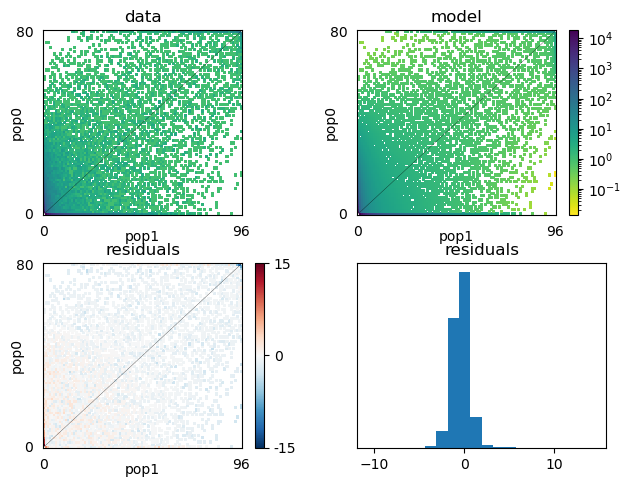

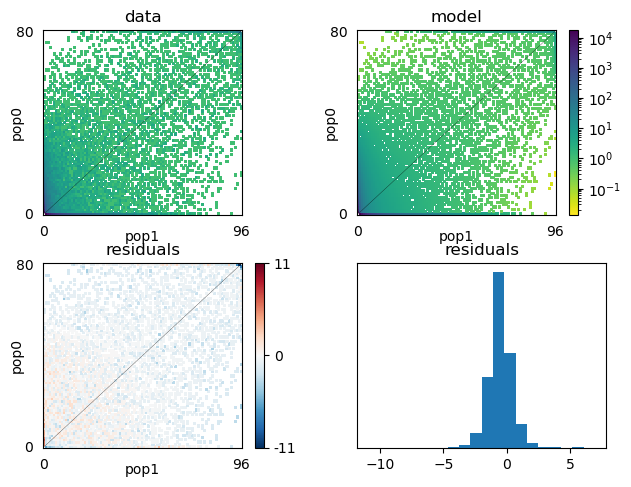

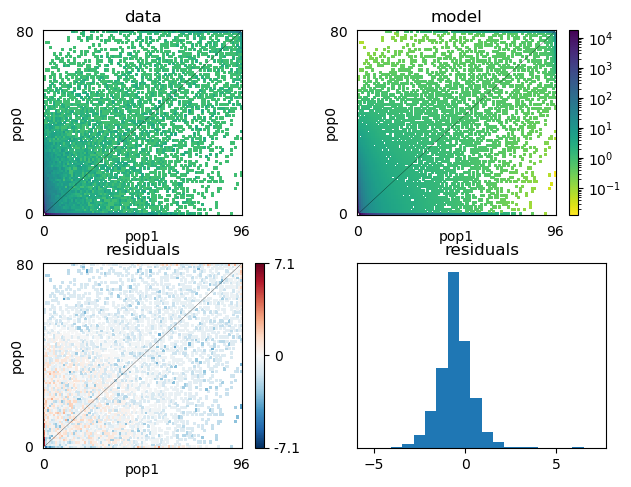

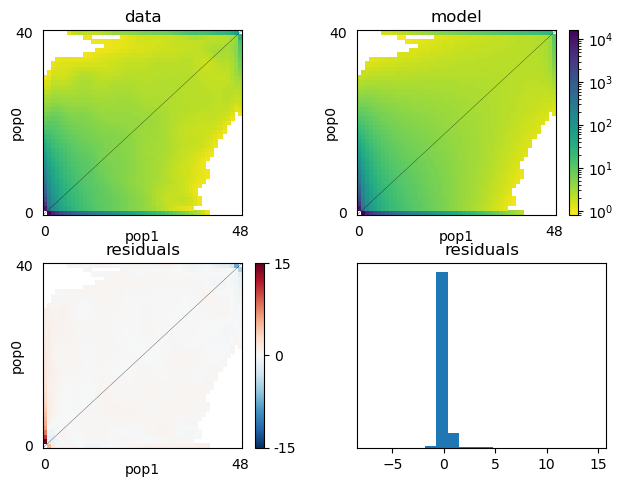

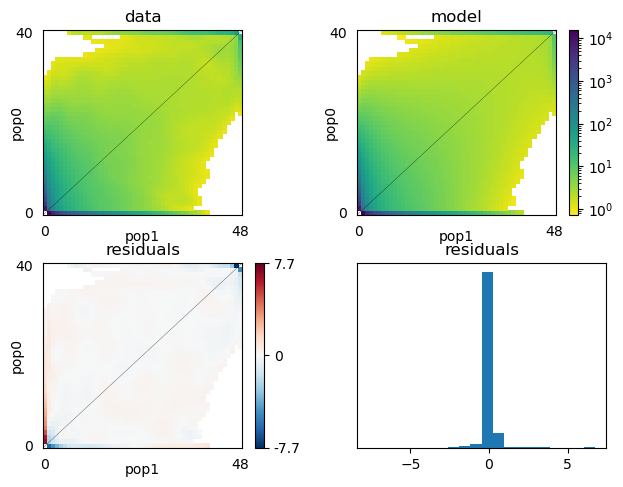

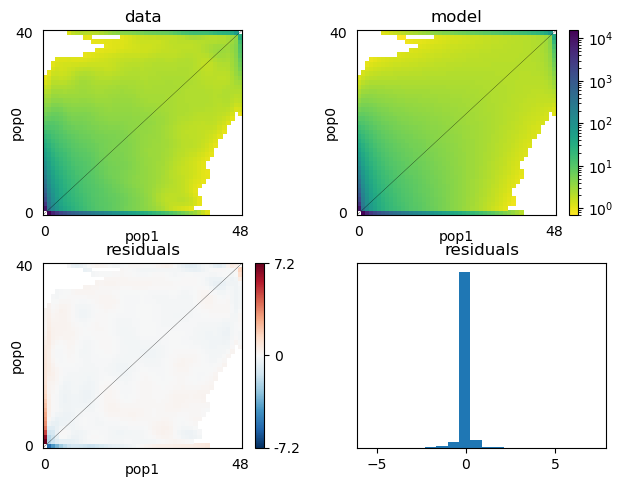

In [16]:
import pickle

cache_1d = pickle.load(open('auto_1d_cache.bpkl', 'rb'))
cache_2d = pickle.load(open('auto_2d_cache.bpkl', 'rb'))

cache_1d_misid = pickle.load(open('auto_misid_1d_cache.bpkl', 'rb'))
cache_2d_misid = pickle.load(open('auto_misid_2d_cache.bpkl', 'rb'))

mixture_DFE = dadi.DFE.mixture

mixture_DFE_misid = dadi.Numerics.make_anc_state_misid_func(mixture_DFE)

lnorm_1d = dadi.DFE.PDFs.lognormal
lnorm_2d = dadi.DFE.PDFs.biv_lognormal

p_best_DFE = [1.4611088963214451, 2.213747124443572, 0.0, 0.0325358883101377]
theta_best_DFE = 14152.626041372287

p_best_DFE_misid = [1.4559333700235704, 2.155822050600934, 0.0, 0.03853099031545915, 0.0032428418005085564]
theta_best_DFE_misid = 13835.549011491255

p_true_DFE = [1.69155136, 2.37871223, 0.0, 0.075]
theta_true_DFE = 4 * 7e-9 * (2.5/3.5) * 5e6 * 161744

ns = nonsyn.sample_sizes

nonsyn.mask[np.where(nonsyn.data == 0)] = True

print("True")
nonsyn_true = mixture_DFE(p_true_DFE, ns, cache_1d, cache_2d, lnorm_1d, lnorm_2d, theta_true_DFE, None)
print('Best fit w/o misid')
nonsyn_best = mixture_DFE(p_best_DFE, ns, cache_1d, cache_2d, lnorm_1d, lnorm_2d, theta_best_DFE, None)
print('Best fit w/ misid')
nonsyn_best_misid = mixture_DFE_misid(p_best_DFE_misid, ns, cache_1d_misid, cache_2d_misid, lnorm_1d, lnorm_2d, theta_best_DFE_misid, None)

dadi.Plotting.plot_2d_comp_Poisson(nonsyn_true, nonsyn)
dadi.Plotting.plot_2d_comp_Poisson(nonsyn_best, nonsyn)
dadi.Plotting.plot_2d_comp_Poisson(nonsyn_best_misid, nonsyn)

# and the down-projected data
ns_dp = nonsyn_dp.sample_sizes

nonsyn_true_dp = nonsyn_true.project(ns_dp)
nonsyn_best_dp = nonsyn_best.project(ns_dp)
nonsyn_best_misid_dp = nonsyn_best_misid.project(ns_dp)

nonsyn_dp.mask[np.where(nonsyn_dp.data == 0)] = True
dadi.Plotting.plot_2d_comp_Poisson(nonsyn_true_dp, nonsyn_dp)
dadi.Plotting.plot_2d_comp_Poisson(nonsyn_best_dp, nonsyn_dp)
dadi.Plotting.plot_2d_comp_Poisson(nonsyn_best_misid_dp, nonsyn_dp)


In [7]:
# separate from all the above focused on down-projection, 
# we can also try to visualize via marginalization

# reload to avoid masking issues
nonsyn = dadi.Spectrum.from_file('nonsyn_sfs.sfs')
syn = dadi.Spectrum.from_file('syn_sfs.sfs')

syn_dip = syn.marginalize([1])
syn_auto = syn.marginalize([0])

nonsyn_dip = nonsyn.marginalize([1])
nonsyn_auto = nonsyn.marginalize([0])



Best Fit Model w/o misid


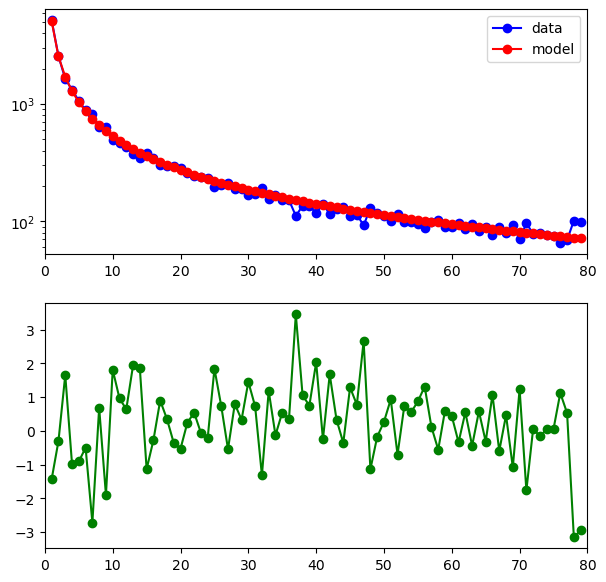

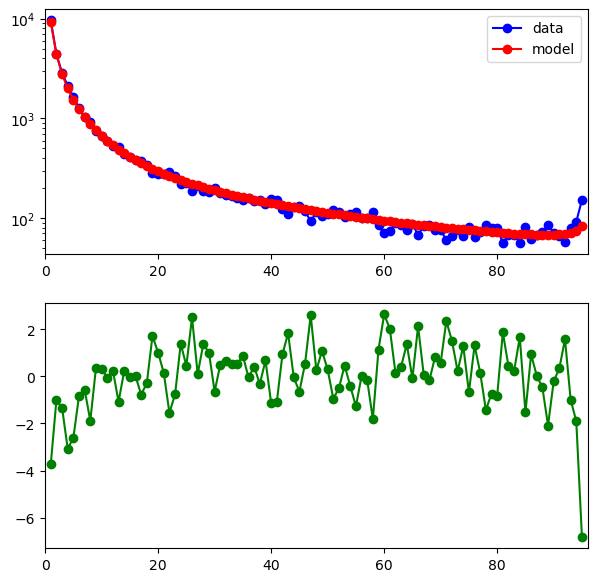

Best Fit Model w/ misid


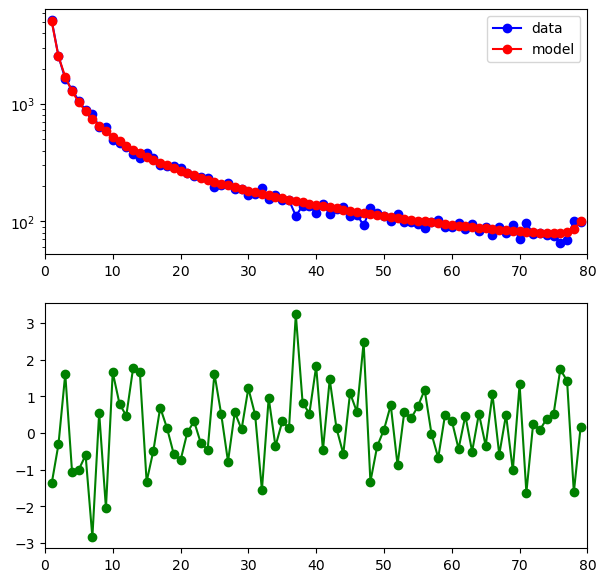

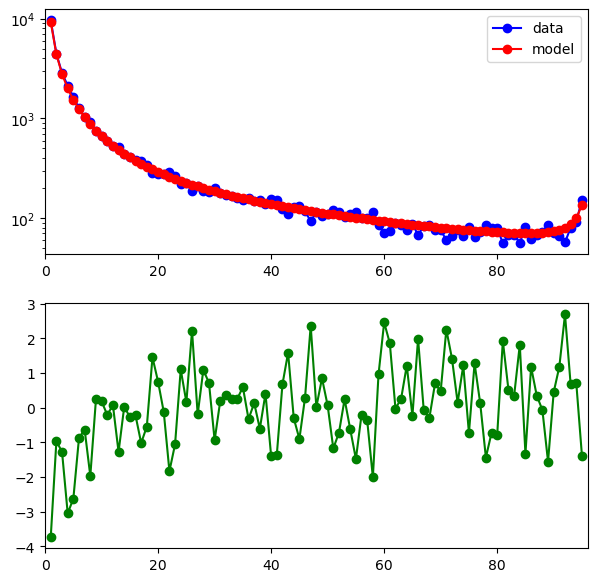

True Model


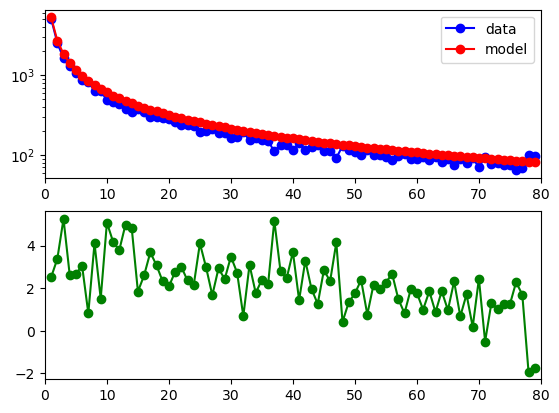

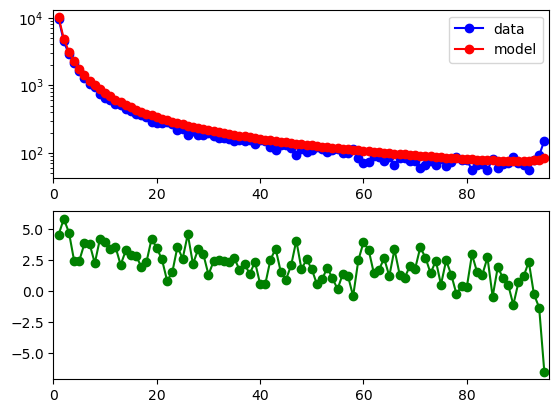

In [12]:
# the synonymous models
syn_dip_model = syn_model.marginalize([1])
syn_auto_model = syn_model.marginalize([0])

syn_dip_true = syn_model_true.marginalize([1])
syn_auto_true = syn_model_true.marginalize([0])

syn_dip_misid = syn_model_misid.marginalize([1])
syn_auto_misid = syn_model_misid.marginalize([0])

# plot
print("Best Fit Model w/o misid")
dadi.Plotting.plot_1d_comp_Poisson(syn_dip_model, syn_dip, fig_num=1000)
dadi.Plotting.plot_1d_comp_Poisson(syn_auto_model, syn_auto, fig_num=1001)

print("Best Fit Model w/ misid")
dadi.Plotting.plot_1d_comp_Poisson(syn_dip_misid, syn_dip, fig_num=1002)
dadi.Plotting.plot_1d_comp_Poisson(syn_auto_misid, syn_auto, fig_num=1003)

print("True Model")
dadi.Plotting.plot_1d_comp_Poisson(syn_dip_true, syn_dip)
dadi.Plotting.plot_1d_comp_Poisson(syn_auto_true, syn_auto)


Best Fit Model w/o misid


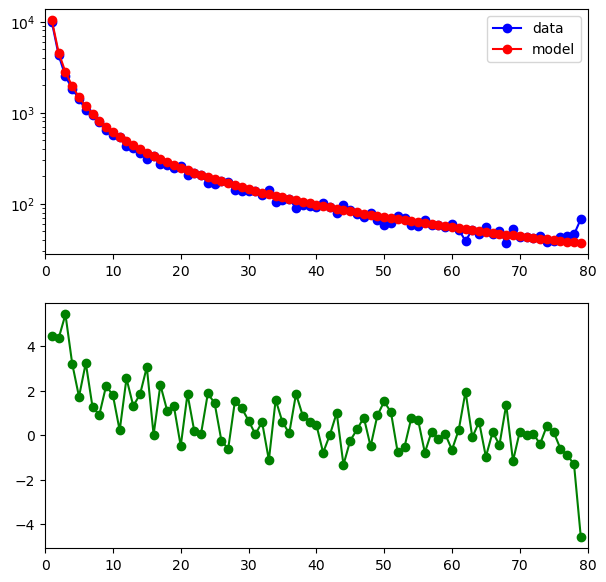

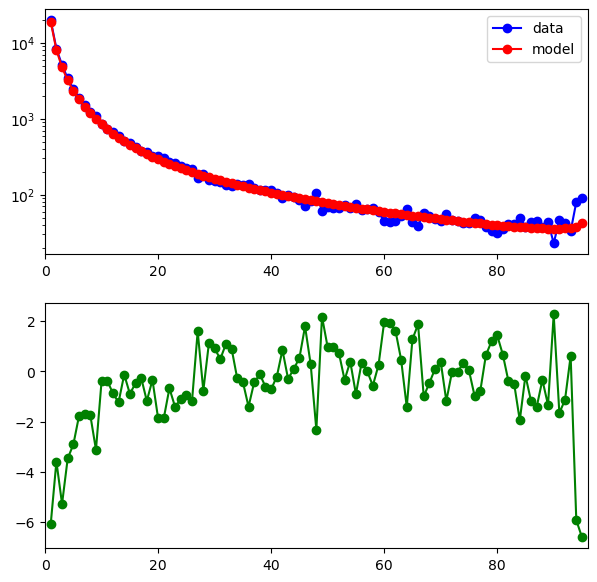

Best Fit Model w/ misid


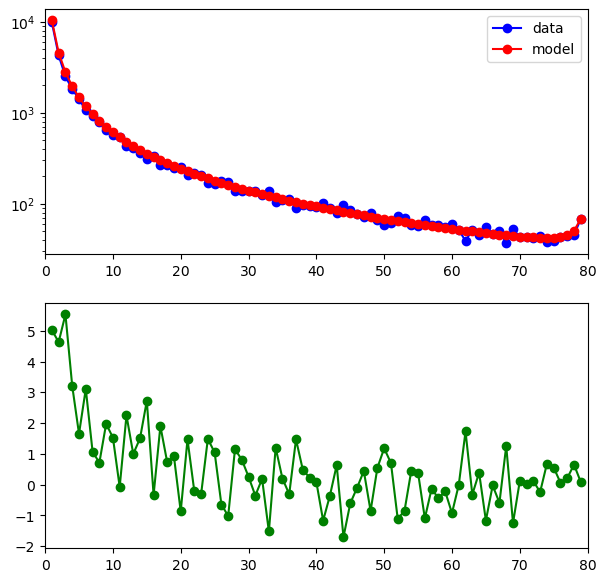

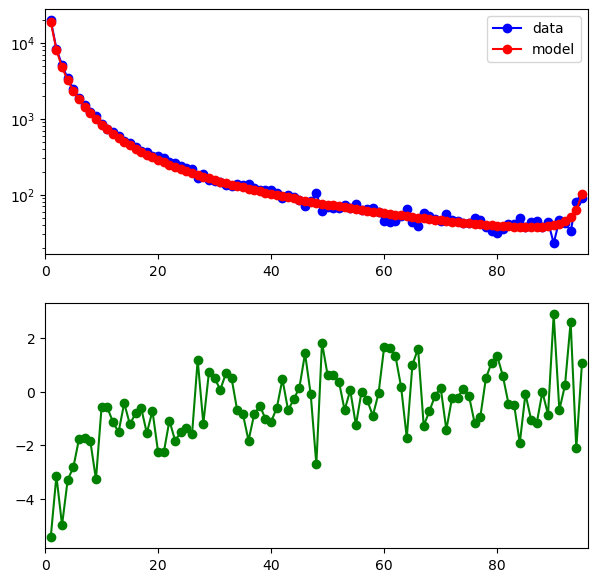

True Model


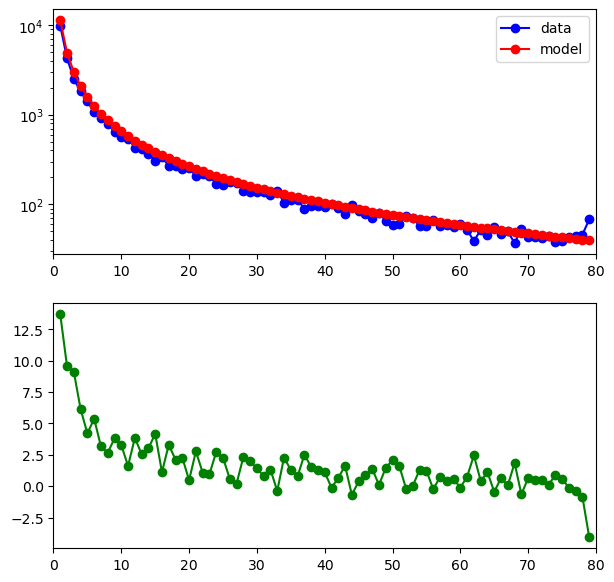

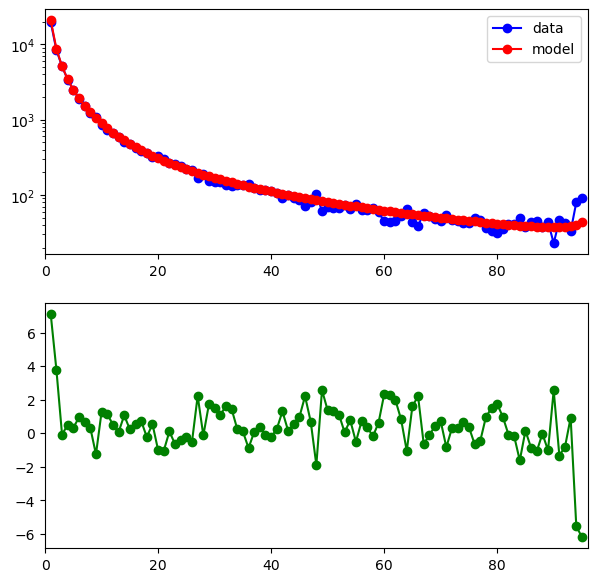

In [19]:
# the nonsynonymous models
nonsyn_dip_model = nonsyn_best.marginalize([1])
nonsyn_auto_model = nonsyn_best.marginalize([0])

nonsyn_dip_misid = nonsyn_best_misid.marginalize([1])
nonsyn_auto_misid = nonsyn_best_misid.marginalize([0])

nonsyn_dip_true = nonsyn_true.marginalize([1])
nonsyn_auto_true = nonsyn_true.marginalize([0])

# plot
print("Best Fit Model w/o misid")
dadi.Plotting.plot_1d_comp_Poisson(nonsyn_dip_model, nonsyn_dip, fig_num=1000)
dadi.Plotting.plot_1d_comp_Poisson(nonsyn_auto_model, nonsyn_auto, fig_num=1001)

print("Best Fit Model w/ misid")
dadi.Plotting.plot_1d_comp_Poisson(nonsyn_dip_misid, nonsyn_dip, fig_num=1002)
dadi.Plotting.plot_1d_comp_Poisson(nonsyn_auto_misid, nonsyn_auto, fig_num=1003)

print("True Model")
dadi.Plotting.plot_1d_comp_Poisson(nonsyn_dip_true, nonsyn_dip, fig_num=1004)
dadi.Plotting.plot_1d_comp_Poisson(nonsyn_auto_true, nonsyn_auto, fig_num=1005)

In [ ]:
p_true = [0.15, 0.15, 0.3, 0.7, 0.8, 0.0, 2.0]

ns = nonsyn.sample_sizes
print(ns)

pts_l = [max(ns)+141, max(ns)+151, max(ns)+161]

demo_sel_model_1d = dadi.Polyploidy.auto_demographics_sel.bottlegrowth_dip_size_change_asym_mig_sel_single_gamma
demo_sel_model_2d = dadi.Polyploidy.auto_demographics_sel.bottlegrowth_dip_size_change_asym_mig_sel

cache = dadi.DFE.Cache1D(p_true, ns, demo_sel_model_1d, pts=pts_l,
                               gamma_bounds=[1e-4, 2000], gamma_pts=50,
                               cpus=50, verbose=True)

# Check for negative values
if (cache.spectra < 0).sum() > 0:
    min_val = cache.spectra.min()
    print(f"\n!!!WARNING!!!")
    print(f"Potentially large negative values!")
    print(f"Most negative value is: {min_val}")
    if min_val < -0.001:
        print(f"Consider rerunning with larger pts_l values")

with open('true_params_1d_cache.bpkl', 'wb') as f:
        pickle.dump(cache, f, protocol=2)


cache = dadi.DFE.Cache2D(p_true, ns, demo_sel_model_2d, pts=pts_l,
                               gamma_bounds=[1e-4, 2000], gamma_pts=50,
                               cpus=50, verbose=True)

# Check for negative values
if (cache.spectra < 0).sum() > 0:
    min_val = cache.spectra.min()
    print(f"\n!!!WARNING!!!")
    print(f"Potentially large negative values!")
    print(f"Most negative value is: {min_val}")
    if min_val < -0.001:
        print(f"Consider rerunning with larger pts_l values")

with open('true_params_2d_cache.bpkl', 'wb') as f:
        pickle.dump(cache, f, protocol=2)


[80 96]
9: -91.20622615168256


  File "/Users/srgib/GitHub/dadi/dadi/DFE/Cache1D_mod.py", line 123, in _worker_sfs
    sfs = popn_func_ex(tuple(params)+(gamma,), ns, pts)
  File "/Users/srgib/GitHub/dadi/dadi/Numerics.py", line 396, in extrap_func
    result_l = list(map(partial_func, pts_l))
  File "/Users/srgib/GitHub/dadi/dadi/Polyploidy/auto_demographics_sel.py", line 833, in bottlegrowth_dip_size_change_asym_mig_sel_single_gamma
    return bottlegrowth_dip_size_change_asym_mig_sel((T_WGD, T_dip, nuB, nuF, nu_dip, m12, m21, gamma, gamma), ns, pts)
  File "/Users/srgib/GitHub/dadi/dadi/Polyploidy/auto_demographics_sel.py", line 513, in bottlegrowth_dip_size_change_asym_mig_sel
    phi = PolyInt.two_pops(phi, xx, T_total, nu1=nu_dip, nu2=nu_func, m12=m12, m21=m21,
  File "/Users/srgib/GitHub/dadi/dadi/Polyploidy/Integration.py", line 1214, in two_pops
    PolyInt.implicit_2Dy(phi, xx, yy, nu2, m21, sel2,
  File "/Users/srgib/GitHub/dadi/dadi/DFE/Cache1D_mod.py", line 123, in _worker_sfs
    sfs = popn_func_ex(tupl

KeyboardInterrupt: 

In [38]:
4 * 7e-9/3.5 * 5e6 * 161744

6469.76